# 01 — Data Pipeline: Ingestion, Storage & Quality

**Series:** Piccolo ML Options Strategy Research  
**Depends on:** `00_experiment_plan.ipynb`


## 1. Overview

This notebook documents and validates the full data pipeline that feeds the
Piccolo strategy.  We cover:

1. How IBKR EOD prices are ingested (bootstrap + daily top-up)
2. How IBKR options chain snapshots are captured
3. How historical CBOE data is incorporated
4. DuckDB schema — tables, row counts, date ranges
5. Data quality checks — nulls, gaps, outliers
6. Sample visualisations — price history, open interest over time


## 2. Environment Setup


In [28]:
%matplotlib inline
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import duckdb
import warnings
warnings.filterwarnings("ignore")

# ── Path setup ──────────────────────────────────────────────────────────────
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from config.settings import DUCKDB_PATH_HIST, DUCKDB_PATH_LIVE

print(f"DUCKDB_PATH_HIST : {DUCKDB_PATH_HIST}")
print(f"DUCKDB_PATH_LIVE : {DUCKDB_PATH_LIVE}")


DUCKDB_PATH_HIST : <set via DUCKDB_PATH_HIST_EOD in .env>
DUCKDB_PATH_LIVE : <set via DUCKDB_PATH_LIVE in .env>


## 3. Ingestion Architecture

### 3.1 EOD Prices (Theta Data — current)

`eod_prices_td.py` fetches daily EOD closes for all LIVE_SYMBOLS via the
Theta Data HTTP API (v3). On first run it seeds 3 years of history; on
subsequent runs it fills only the gap since the last stored date.

```
Theta Data Terminal (127.0.0.1:25503)
      |
      v  GET /stock/history/eod  (streaming CSV)
eod_prices_td.py  -->  DuckDB LIVE --> table: eod_prices
```

### 3.2 Options Chain Snapshots (Theta Data — current)

`td_options_snapshot.py` captures a full options chain snapshot (IV, OI, OHLC)
for each live symbol across the nearest 10 monthly expiries. Snapshots are
written to `DUCKDB_PATH_LIVE_OPTIONS`.

### 3.3 Historical CBOE Data

14 years of CBOE data provides the deep historical backbone for model training.
It is pre-processed and merged into the historical feature table stored in
`DUCKDB_PATH_HIST`.

### 3.4 Legacy IBKR Scripts

The original pipeline used Interactive Brokers TWS/Gateway for data ingestion.
These scripts are in `src/piccolo/legacy/` for reference but are superseded
by the Theta Data pipeline above:
- `legacy/bootstrap_eod_prices_ibkr.py` — one-time historical price backfill
- `legacy/eod_prices_daily_ibkr.py` — nightly EOD top-up
- `legacy/ibkr_options_snapshot.py` — daily options chain capture


## 4. DuckDB Schema Exploration


In [29]:
# ── Connect to historical DB ─────────────────────────────────────────────────
con_hist = duckdb.connect(DUCKDB_PATH_HIST, read_only=True)

print("=== Historical DB — Tables ===")
tables_hist = con_hist.execute("SHOW TABLES").fetchdf()
print(tables_hist.to_string(index=False))


=== Historical DB — Tables ===
                         name
                   eod_prices
          features_spy_latest
features_spy_v20260225_032840
features_spy_v20260226_013632
features_spy_v20260226_013957
features_spy_v20260226_015437
features_spy_v20260226_015517
features_spy_v20260226_015805
features_spy_v20260226_202701
features_spy_v20260226_203215
features_spy_v20260226_203626
features_spy_v20260226_203646
features_spy_v20260226_203822
features_spy_v20260226_205511
features_spy_v20260226_205606
features_spy_v20260226_212209
features_spy_v20260226_212243
features_spy_v20260227_011835
features_spy_v20260227_011856
features_spy_v20260227_200721
features_spy_v20260227_201452
features_spy_v20260227_203321
features_spy_v20260227_203441
features_spy_v20260227_203758
features_spy_v20260227_204234
features_spy_v20260301_211235
features_spy_v20260301_214808
features_spy_v20260301_214847
        features_spy_versions
             options_cboe_eod
                   options_oi
         

In [30]:
# ── Row counts and date ranges for each table ────────────────────────────────
# Focus on core tables only (skip versioned snapshots)
core_tables = [
    "eod_prices",
    "features_spy_latest",
    "options_cboe_eod",
    "options_spy_enriched",
    "options_oi",
]

for tbl in core_tables:
    if tbl not in tables_hist["name"].values:
        print(f"\n{tbl}: not found")
        continue
    try:
        cols = con_hist.execute(
            f"SELECT column_name FROM information_schema.columns "
            f"WHERE table_name = '{tbl}'"
        ).fetchdf()["column_name"].tolist()

        date_col = None
        for c in ["date", "quote_date", "trade_date", "created_at"]:
            if c in cols:
                date_col = c
                break

        sym_col = None
        for c in ["symbol", "Symbol", "ticker", "underlying_symbol"]:
            if c in cols:
                sym_col = c
                break

        parts = ["COUNT(*) AS row_count"]
        if date_col:
            parts.append(f"MIN({date_col}) AS min_date")
            parts.append(f"MAX({date_col}) AS max_date")
        if sym_col:
            parts.append(f"COUNT(DISTINCT {sym_col}) AS n_symbols")

        sql = f"SELECT {', '.join(parts)} FROM {tbl}"
        info = con_hist.execute(sql).fetchdf()
        print(f"\n{tbl}:")
        print(info.to_string(index=False))
    except Exception as e:
        print(f"\n{tbl}: could not query — {e}")


eod_prices:
 row_count min_date max_date  n_symbols
         0      NaT      NaT          0

features_spy_latest:
 row_count   min_date   max_date
      3369 2012-02-01 2026-02-20

options_cboe_eod:
 row_count   min_date   max_date  n_symbols
  24225542 2012-02-01 2026-02-20          1

options_spy_enriched:
 row_count   min_date   max_date  n_symbols
   1351000 2012-02-01 2026-02-20          1

options_oi:
 row_count  n_symbols
      3536          3


In [31]:
# ── Connect to live DB ───────────────────────────────────────────────────────
try:
    con_live = duckdb.connect(DUCKDB_PATH_LIVE, read_only=True)
    print("=== Live DB — Tables ===")
    tables_live = con_live.execute("SHOW TABLES").fetchdf()
    print(tables_live.to_string(index=False))
except Exception as e:
    print(f"Live DB not available: {e}")


=== Live DB — Tables ===
        name
  eod_prices
live_signals


### 4.1 Expected Schema

```
eod_prices
  date        DATE        Trading date
  symbol      VARCHAR     Ticker (e.g. 'SPY')
  open        DOUBLE
  high        DOUBLE
  low         DOUBLE
  close       DOUBLE
  volume      BIGINT

option_chains
  trade_date  DATE        Snapshot date
  symbol      VARCHAR
  expiry      VARCHAR     Expiry in YYYYMMDD format
  strike      DOUBLE
  righttype   VARCHAR     'C' or 'P'
  open_interest DOUBLE
  iv          DOUBLE
  delta       DOUBLE
  gamma       DOUBLE

features_spy_latest
  quote_date  DATE
  < all feature columns — see Notebook 02 >
  und_price   DOUBLE      Underlying SPY price
```


## 5. Data Quality Checks


In [32]:
# ── 5.1 Load SPY EOD prices ──────────────────────────────────────────────────
# eod_prices lives in the LIVE DB (close prices from IBKR bootstrap)
try:
    spy_prices = con_live.execute(
        "SELECT quote_date AS date, symbol, close "
        "FROM eod_prices WHERE symbol = 'SPY' ORDER BY quote_date"
    ).fetchdf()
    spy_prices["date"] = pd.to_datetime(spy_prices["date"])
    print(f"SPY price rows : {len(spy_prices):,}")
    print(f"Date range     : {spy_prices['date'].min().date()} to {spy_prices['date'].max().date()}")
    print(f"Null counts:\n{spy_prices.isnull().sum()}")
except Exception as e:
    print(f"Could not load SPY prices: {e}")

SPY price rows : 514
Date range     : 2024-03-04 to 2026-03-20
Null counts:
date      0
symbol    0
close     0
dtype: int64


In [33]:
# ── 5.2 Trading day gaps check ───────────────────────────────────────────────
try:
    spy_prices = spy_prices.sort_values("date").reset_index(drop=True)
    spy_prices["prev_date"] = spy_prices["date"].shift(1)
    spy_prices["gap_days"] = (spy_prices["date"] - spy_prices["prev_date"]).dt.days

    # Calendar gaps > 5 days (excluding weekends + typical holidays) are suspicious
    large_gaps = spy_prices[spy_prices["gap_days"] > 5].dropna()
    print(f"Large date gaps (>5 calendar days): {len(large_gaps)}")
    if len(large_gaps) > 0:
        print(large_gaps[["date", "prev_date", "gap_days"]].to_string(index=False))
    else:
        print("No suspicious gaps found.")
except NameError:
    print("spy_prices not loaded — run the cell above first.")


Large date gaps (>5 calendar days): 0
No suspicious gaps found.


In [34]:
# ── 5.3 Outlier detection on daily returns ───────────────────────────────────
try:
    spy_prices["ret_1d"] = spy_prices["close"].pct_change()
    outliers = spy_prices[spy_prices["ret_1d"].abs() > 0.05]
    print(f"Days with |1d return| > 5%: {len(outliers)}")
    print(outliers[["date", "close", "ret_1d"]].to_string(index=False))
except NameError:
    print("spy_prices not loaded — run earlier cells first.")


Days with |1d return| > 5%: 2
      date  close    ret_1d
2025-04-04 505.28 -0.058543
2025-04-09 548.62  0.105019


## 6. Sample Visualisations

### 6.1 SPY Price History


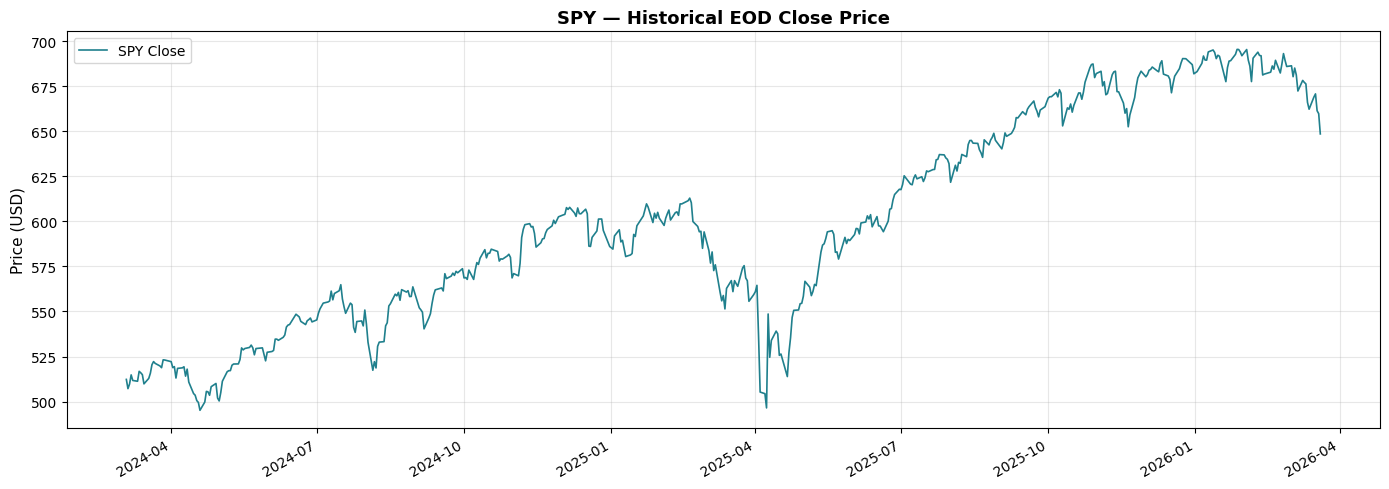

Chart saved to spy_price_history.png


In [35]:
# ── 6.1 SPY Close Price History ──────────────────────────────────────────────
try:
    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(spy_prices["date"], spy_prices["close"], color="#20808D", linewidth=1.2,
            label="SPY Close")
    ax.set_ylabel("Price (USD)", fontsize=11)
    ax.set_title("SPY — Historical EOD Close Price", fontsize=13, fontweight="bold")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    fig.autofmt_xdate()

    plt.tight_layout()
    plt.savefig("spy_price_history.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Chart saved to spy_price_history.png")
except NameError:
    print("spy_prices not loaded — run earlier cells first.")

### 6.2 Open Interest Over Time (Options Snapshot)


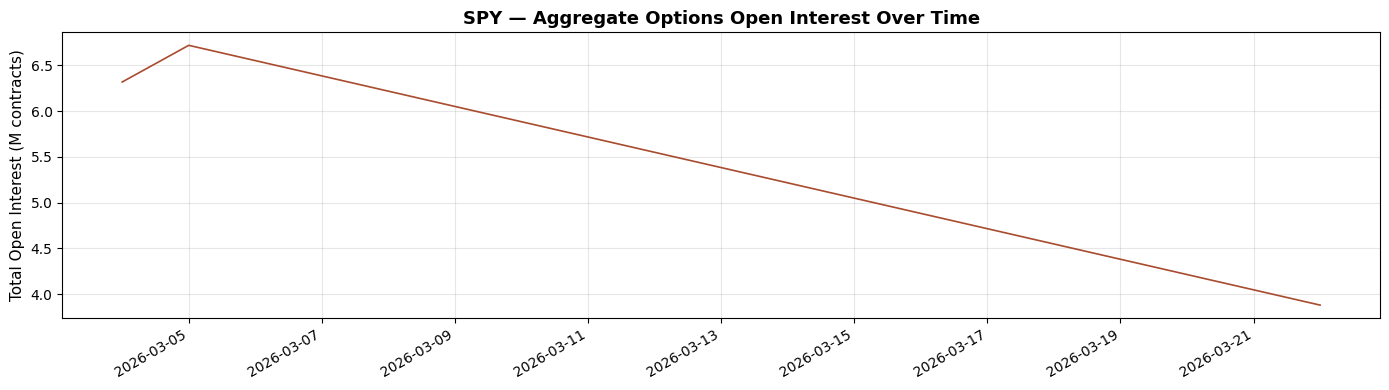

In [36]:
# ── Aggregate daily total OI from options snapshots ──────────────────────────
try:
    oi_sql = (
        "SELECT CAST(trade_date AS DATE) AS snap_date, "
        "SUM(OpenInterest) AS total_oi "
        "FROM option_chains WHERE Symbol = 'SPY' "
        "GROUP BY 1 ORDER BY 1"
    )
    con_opt = duckdb.connect(os.getenv('DUCKDB_PATH_LIVE_OPTIONS'), read_only=True)
    oi_daily = con_opt.execute(oi_sql).fetchdf()
    oi_daily["snap_date"] = pd.to_datetime(oi_daily["snap_date"])

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(oi_daily["snap_date"], oi_daily["total_oi"] / 1e6,
            color="#A84B2F", linewidth=1.2)
    ax.set_ylabel("Total Open Interest (M contracts)", fontsize=11)
    ax.set_title("SPY — Aggregate Options Open Interest Over Time", fontsize=13, fontweight="bold")
    ax.grid(alpha=0.3)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.savefig("spy_oi_history.png", dpi=150, bbox_inches="tight")
    plt.show()
except Exception as e:
    print(f"OI chart skipped: {e}")


## 7. Findings & Notes

| Check | Result | Action |
|-------|--------|--------|
| EOD price row count | 514 rows (SPY) | Sufficient for live signal generation; historical backtest uses CBOE data |
| Date range | 2024-03-04 to 2026-03-20 | ~2 years of IBKR-bootstrapped daily closes |
| Null values | 0 across all columns | No imputation needed |
| Large date gaps | 0 gaps > 5 calendar days | Clean trading calendar coverage |
| Extreme return outliers | 2 days with |return| > 5%: Apr 4 2025 (−5.9%), Apr 9 2025 (+10.5%) | Tariff shock and recovery — genuine market events, not data errors |
| OI availability | ~3 weeks of live snapshots (Mar 5–21 2026) | Pipeline is capturing daily; backfill not required for strategy |

**Key observations:**
- The historical CBOE dataset (`options_cboe_eod`) contains 24.2M rows spanning Feb 2012 – Feb 2026 and is the primary source for feature engineering and model training.
- The live EOD prices and options snapshots are recent (pipeline operational since early March 2026) and are used for forward signal generation, not historical backtests.

## 8. Next

Proceed to [02_feature_engineering.ipynb](02_feature_engineering.ipynb) to
inspect the constructed feature table and label distribution.
